# 🌾 SahelCropCast — Crop Yield Prediction Using Machine Learning
### Algorithm: Random Forest
### Dataset: FAO FAOSTAT (1990-2024) + NASA POWER Climate Data
### Region: West & Central Africa (13 Countries, 100 Crops)
### Author: SHU CYRIL NDONWI | UBa23PH131 | University of Bamenda COLTECH

## CELL 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import warnings
warnings.filterwarnings('ignore')
print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## CELL 2 — Load Dataset

In [2]:
df = pd.read_csv('final_dataset.csv')
print('✅ Dataset loaded!')
print('Shape:', df.shape)
print('Countries:', df['Area'].nunique())
print('Crops:', df['Item'].nunique())
print('Years:', df['Year'].min(), '-', df['Year'].max())
print('Columns:', df.columns.tolist())
df.head()

✅ Dataset loaded!
Shape: (19460, 10)
Countries: 13
Crops: 100
Years: 1990 - 2024
Columns: ['Area', 'Item', 'Year', 'yield_kg_per_ha', 'rainfall_mm_year', 'avg_temp_c', 'soil_moisture', 'temp_range_c', 'Area_encoded', 'Item_encoded']


,Area,Item,Year,yield_kg_per_ha,rainfall_mm_year,avg_temp_c,soil_moisture,temp_range_c,Area_encoded,Item_encoded
0,Cameroon,Apricots,1990,3977.8,1463.65,23.41,0.63,11.358987,2,1
1,Cameroon,Apricots,1991,4485.7,1237.35,23.34,0.62,11.358987,2,1
2,Cameroon,Apricots,1992,4455.7,1624.25,23.02,0.65,11.358987,2,1
3,Cameroon,Apricots,1993,4456.5,1781.20,22.99,0.74,11.358987,2,1
4,Cameroon,Apricots,1994,4465.1,1708.20,22.94,0.73,11.358987,2,1


## CELL 3 — Explore Data

In [3]:
print('Missing Values:\n', df.isnull().sum())
print('\nCountries:', sorted(df['Area'].unique().tolist()))
print('\nCameroon rows:', len(df[df['Area']=='Cameroon']))
print('\nTarget variable stats:')
print(df['yield_kg_per_ha'].describe())
df.head()

Missing Values:
 Area                0
Item                0
Year                0
yield_kg_per_ha     0
rainfall_mm_year    0
avg_temp_c          0
soil_moisture       0
temp_range_c        0
Area_encoded        0
Item_encoded        0
dtype: int64

Countries: ['Benin', 'Burkina Faso', 'Cameroon', "Côte d'Ivoire", 'Ghana', 'Guinea', 'Liberia', 'Mali', 'Niger', 'Nigeria', 'Senegal', 'Sierra Leone', 'Togo']

Cameroon rows: 2316

Target variable stats:
count     19460.000000
mean       6438.269301
std       11180.017113
min           7.000000
25%         833.300000
50%        2581.500000
75%        7828.200000
max      120096.200000
Name: yield_kg_per_ha, dtype: float64


,Area,Item,Year,yield_kg_per_ha,rainfall_mm_year,avg_temp_c,soil_moisture,temp_range_c,Area_encoded,Item_encoded
0,Cameroon,Apricots,1990,3977.8,1463.65,23.41,0.63,11.358987,2,1
1,Cameroon,Apricots,1991,4485.7,1237.35,23.34,0.62,11.358987,2,1
2,Cameroon,Apricots,1992,4455.7,1624.25,23.02,0.65,11.358987,2,1
3,Cameroon,Apricots,1993,4456.5,1781.20,22.99,0.74,11.358987,2,1
4,Cameroon,Apricots,1994,4465.1,1708.20,22.94,0.73,11.358987,2,1


## CELL 4 — Clean and Encode Data

In [4]:
# Drop any missing values
df = df.dropna().reset_index(drop=True)

# Encode categorical columns using Label Encoding
le_area = LabelEncoder()
le_item = LabelEncoder()

df['Area_encoded'] = le_area.fit_transform(df['Area'])
df['Item_encoded'] = le_item.fit_transform(df['Item'])

print('✅ Data cleaned and encoded!')
print('Cleaned shape:', df.shape)
print('Countries encoded:', len(le_area.classes_))
print('Crops encoded:', len(le_item.classes_))
df.head()

✅ Data cleaned and encoded!
Cleaned shape: (19460, 10)
Countries encoded: 13
Crops encoded: 100


,Area,Item,Year,yield_kg_per_ha,rainfall_mm_year,avg_temp_c,soil_moisture,temp_range_c,Area_encoded,Item_encoded
0,Cameroon,Apricots,1990,3977.8,1463.65,23.41,0.63,11.358987,2,1
1,Cameroon,Apricots,1991,4485.7,1237.35,23.34,0.62,11.358987,2,1
2,Cameroon,Apricots,1992,4455.7,1624.25,23.02,0.65,11.358987,2,1
3,Cameroon,Apricots,1993,4456.5,1781.20,22.99,0.74,11.358987,2,1
4,Cameroon,Apricots,1994,4465.1,1708.20,22.94,0.73,11.358987,2,1


## CELL 5 — Split Features and Target

In [5]:
# Features: Country, Crop, Year, Rainfall, Temperature, Soil Moisture, Temp Range
X = df[['Area_encoded', 'Item_encoded', 'Year',
        'rainfall_mm_year', 'avg_temp_c', 'soil_moisture', 'temp_range_c']]

# Target: Crop Yield in kg/ha
y = df['yield_kg_per_ha']

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print('✅ Data split successfully!')
print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)

✅ Data split successfully!
Training size: (15568, 7)
Testing size: (3892, 7)


## CELL 6 — Train Random Forest Model

In [6]:
# Train Random Forest Regressor
# n_estimators=15: 15 trees (keeps file size small for GitHub deployment)
# max_depth=20: prevents overfitting
# random_state=42: ensures reproducibility

rf_model = RandomForestRegressor(
    n_estimators=15,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print('✅ Random Forest model trained successfully!')
print(f'Number of trees: {rf_model.n_estimators}')

✅ Random Forest model trained successfully!
Number of trees: 15


## CELL 7 — Evaluate Model Performance

In [7]:
# Make predictions on test set
rf_preds = rf_model.predict(X_test)

# Calculate metrics
mae  = mean_absolute_error(y_test, rf_preds)
rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
r2   = r2_score(y_test, rf_preds)

print('=' * 45)
print('   RANDOM FOREST MODEL PERFORMANCE')
print('=' * 45)
print(f'MAE:      {mae:.2f} kg/ha')
print(f'RMSE:     {rmse:.2f} kg/ha')
print(f'R2 Score: {r2:.4f}')
print('=' * 45)
print(f'\nThe model explains {r2*100:.2f}% of crop yield variation.')

   RANDOM FOREST MODEL PERFORMANCE
MAE:      657.41 kg/ha
RMSE:     1871.10 kg/ha
R2 Score: 0.9724

The model explains 97.24% of crop yield variation.


## CELL 8 — Visualize: Actual vs Predicted

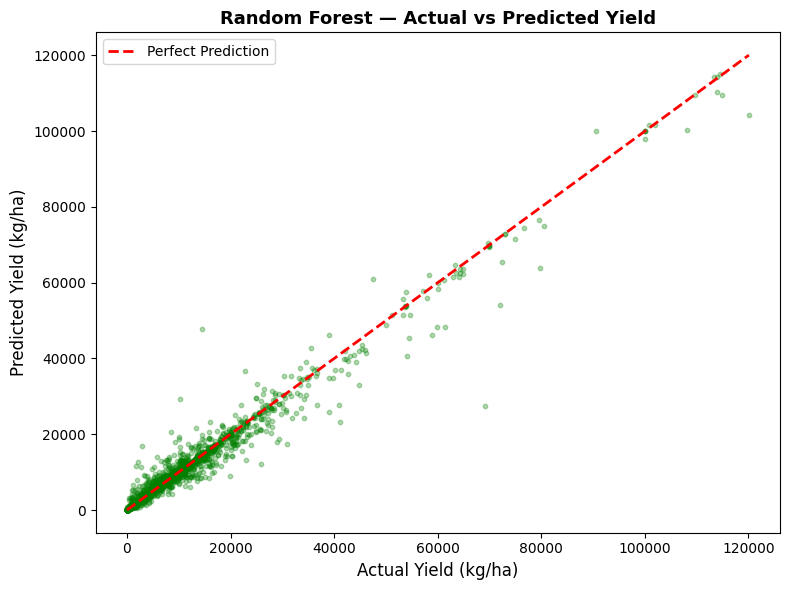

✅ Figure saved as actual_vs_predicted.png


In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.3, color='green', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Yield (kg/ha)', fontsize=12)
plt.ylabel('Predicted Yield (kg/ha)', fontsize=12)
plt.title('Random Forest — Actual vs Predicted Yield', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure saved as actual_vs_predicted.png')

## CELL 9 — Feature Importance

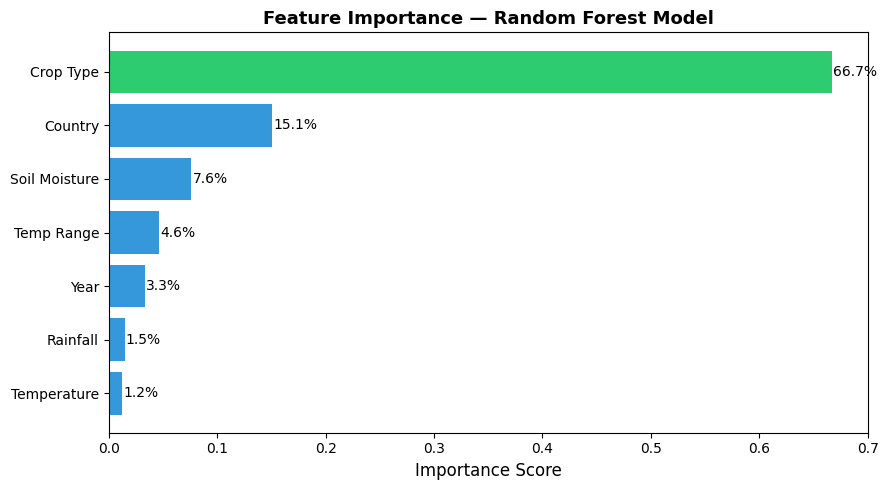

✅ Figure saved as feature_importance.png


In [9]:
feature_names = ['Country', 'Crop Type', 'Year',
                 'Rainfall', 'Temperature', 'Soil Moisture', 'Temp Range']
importances = rf_model.feature_importances_

# Sort by importance
indices = np.argsort(importances)
sorted_names = [feature_names[i] for i in indices]
sorted_imp = importances[indices]

plt.figure(figsize=(9, 5))
colors = ['#2ecc71' if v == max(importances) else '#3498db' for v in sorted_imp]
plt.barh(sorted_names, sorted_imp, color=colors)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Random Forest Model', fontsize=13, fontweight='bold')
for i, v in enumerate(sorted_imp):
    plt.text(v + 0.001, i, f'{v:.1%}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure saved as feature_importance.png')

## CELL 10 — Sample Predictions

In [11]:
# Check exact crop name in dataset
print("Sample crops:", sorted(df['Item'].unique().tolist())[:20])

# Get first available crop for Cameroon
cam_data = df[df['Area'] == 'Cameroon']
first_crop = cam_data['Item'].iloc[0]
first_country = 'Cameroon'

cam_enc = le_area.transform([first_country])[0]
crop_enc = le_item.transform([first_crop])[0]

avg_rain   = cam_data['rainfall_mm_year'].mean()
avg_temp   = cam_data['avg_temp_c'].mean()
avg_soil   = cam_data['soil_moisture'].mean()
avg_trange = cam_data['temp_range_c'].mean()

sample = np.array([[cam_enc, crop_enc, 2024,
                    avg_rain, avg_temp, avg_soil, avg_trange]])
pred = rf_model.predict(sample)[0]

print('=' * 45)
print('   SAMPLE PREDICTION')
print('=' * 45)
print(f'Country:         {first_country}')
print(f'Crop:            {first_crop}')
print(f'Year:            2024')
print(f'Predicted Yield: {pred:,.0f} kg/ha')
print('=' * 45)

Sample crops: ['Almonds, in shell', 'Apricots', 'Avocados', 'Bambara beans, dry', 'Bananas', 'Beans, dry', 'Broad beans and horse beans, dry', 'Broad beans and horse beans, green', 'Cabbages', 'Cantaloupes and other melons', 'Carrots and turnips', 'Cashew nuts, in shell', 'Cashewapple', 'Cassava, fresh', 'Castor oil seeds', 'Cereals n.e.c.', 'Chestnuts, in shell', 'Chick peas, dry', 'Chicory roots', 'Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw']
   SAMPLE PREDICTION
Country:         Cameroon
Crop:            Apricots
Year:            2024
Predicted Yield: 5,333 kg/ha


## CELL 11 — Save Model and Encoders

In [12]:
# Save Random Forest model
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save encoders
with open('le_area.pkl', 'wb') as f:
    pickle.dump(le_area, f)

with open('le_item.pkl', 'wb') as f:
    pickle.dump(le_item, f)

import os
size = os.path.getsize('rf_model.pkl') / (1024*1024)

print('✅ All files saved successfully!')
print(f'rf_model.pkl  — Random Forest model ({size:.1f} MB)')
print('le_area.pkl   — Country Label Encoder')
print('le_item.pkl   — Crop Label Encoder')
print('\n🚀 Ready to run: streamlit run app.py')

✅ All files saved successfully!
rf_model.pkl  — Random Forest model (17.0 MB)
le_area.pkl   — Country Label Encoder
le_item.pkl   — Crop Label Encoder

🚀 Ready to run: streamlit run app.py
